Self-consistent Delta0 = 0.0712079345
DOS k-sum progress: 250/2500
DOS k-sum progress: 500/2500
DOS k-sum progress: 750/2500
DOS k-sum progress: 1000/2500
DOS k-sum progress: 1250/2500
DOS k-sum progress: 1500/2500
DOS k-sum progress: 1750/2500
DOS k-sum progress: 2000/2500
DOS k-sum progress: 2250/2500
DOS k-sum progress: 2500/2500


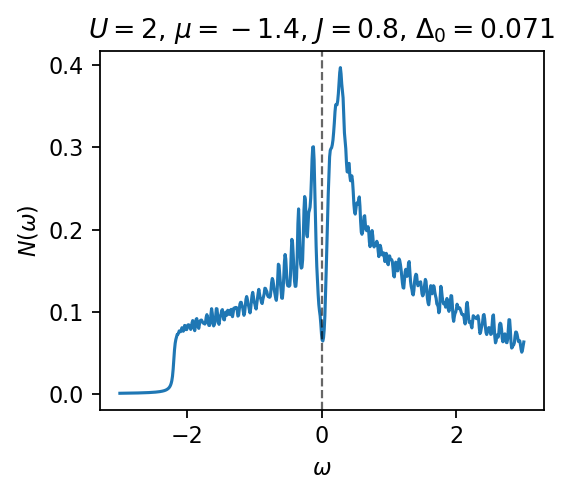

18.027078866958618 seconds


In [ ]:
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize


start_time = time.time()


def lorentzian(x, gamma):
    """Normalized Lorentzian used to broaden delta functions."""
    return gamma / np.pi / (x**2 + gamma**2)


def state_index(occ):
    """Map |n_a, n_b, n_c, n_d> to the integer Fock index."""
    return sum(int(n) << i for i, n in enumerate(occ))


def annihilation_operator(mode, n_modes=4):
    """Fermionic annihilation matrix for one mode in the occupation basis."""
    dim = 2**n_modes
    op = np.zeros((dim, dim), dtype=complex)

    for state in range(dim):
        if not ((state >> mode) & 1):
            continue

        new_state = state & ~(1 << mode)
        occupied_before = sum((state >> j) & 1 for j in range(mode))
        sign = (-1) ** occupied_before
        op[new_state, state] = sign

    return op


def thermal_weights(energies, beta):
    """Boltzmann weights normalized in a numerically stable way."""
    shifted = energies - np.min(energies)
    weights = np.exp(-beta * shifted)
    return weights / np.sum(weights)


def band_energy(kx, ky, mu, hop):
    """
    Dispersion used in wormsc.py:

        xi_k = -2(cos kx + cos ky)
               -4 t1 cos kx cos ky
               -4 t2(cos^2 kx + cos^2 ky - 1) - mu.
    """
    cx = np.cos(kx)
    cy = np.cos(ky)
    t1, t2 = hop
    return (
        -2.0 * (cx + cy)
        - 4.0 * t1 * cx * cy
        - 4.0 * t2 * (cx * cx + cy * cy - 1.0)
        - mu
    )


def pair_form_factor(kx, ky):
    """d-wave form factor cos(kx) - cos(ky)."""
    return np.cos(kx) - np.cos(ky)


def block_matrix_elements(kx, ky, mu, hop, U, Delta0):
    """
    Construct the block matrices for one four-mode Fermi-arc sector.

    Mode order:
        0: a = c_{k up}
        1: b = c_{k+Q down}
        2: c = c_{-k down}
        3: d = c_{-k-Q up}
    """
    xi_k = band_energy(kx, ky, mu, hop)
    xi_kq = band_energy(kx + np.pi, ky + np.pi, mu, hop)
    Delta_k = Delta0 * pair_form_factor(kx, ky)
    d = Delta_k
    dc = np.conjugate(Delta_k)

    h_sz_2 = np.array([[xi_k + xi_kq]], dtype=complex)
    basis_sz_2 = [(1, 0, 0, 1)]

    h_sz_minus_2 = np.array([[xi_k + xi_kq]], dtype=complex)
    basis_sz_minus_2 = [(0, 1, 1, 0)]

    h_sz_1_a = np.array(
        [
            [xi_k, dc],
            [d, xi_k + 2.0 * xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_1_a = [(1, 0, 0, 0), (1, 1, 0, 1)]

    h_sz_1_d = np.array(
        [
            [xi_kq, dc],
            [d, 2.0 * xi_k + xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_1_d = [(0, 0, 0, 1), (1, 0, 1, 1)]

    h_sz_minus_1_b = np.array(
        [
            [xi_kq, -dc],
            [-d, 2.0 * xi_k + xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_minus_1_b = [(0, 1, 0, 0), (1, 1, 1, 0)]

    h_sz_minus_1_c = np.array(
        [
            [xi_k, -dc],
            [-d, xi_k + 2.0 * xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_minus_1_c = [(0, 0, 1, 0), (0, 1, 1, 1)]

    h_sz_0_4 = np.array(
        [
            [0.0, dc, dc, 0.0],
            [d, 2.0 * xi_k, 0.0, -dc],
            [d, 0.0, 2.0 * xi_kq, -dc],
            [0.0, -d, -d, 2.0 * (xi_k + xi_kq + U)],
        ],
        dtype=complex,
    )
    basis_sz_0_4 = [
        (0, 0, 0, 0),
        (1, 0, 1, 0),
        (0, 1, 0, 1),
        (1, 1, 1, 1),
    ]

    h_interacting_pair = np.array([[xi_k + xi_kq + U]], dtype=complex)
    basis_ab = [(1, 1, 0, 0)]
    basis_cd = [(0, 0, 1, 1)]

    return [
        (h_sz_2, basis_sz_2),
        (h_sz_1_a, basis_sz_1_a),
        (h_sz_1_d, basis_sz_1_d),
        (h_sz_0_4, basis_sz_0_4),
        (h_interacting_pair, basis_ab),
        (h_interacting_pair, basis_cd),
        (h_sz_minus_1_b, basis_sz_minus_1_b),
        (h_sz_minus_1_c, basis_sz_minus_1_c),
        (h_sz_minus_2, basis_sz_minus_2),
    ]


def diagonalize_sector_block(kx, ky, mu, hop, U, Delta0):
    """
    Diagonalize all blocks and embed their eigenvectors into the full
    16-dimensional occupation basis of one four-mode sector.
    """
    energies_all = []
    vectors_all = []

    for h_block, basis_occ in block_matrix_elements(kx, ky, mu, hop, U, Delta0):
        energies, vectors = np.linalg.eigh(h_block)
        basis_indices = [state_index(occ) for occ in basis_occ]

        for n in range(len(energies)):
            full_vector = np.zeros(16, dtype=complex)
            full_vector[basis_indices] = vectors[:, n]
            energies_all.append(energies[n])
            vectors_all.append(full_vector)

    order = np.argsort(np.real(energies_all))
    energies_all = np.array(energies_all, dtype=float)[order]
    vectors_all = np.array(vectors_all, dtype=complex).T[:, order]

    return energies_all, vectors_all


def sector_operators():
    """Return annihilation operators and the d-wave pair operator in one sector."""
    c_ops = [annihilation_operator(i) for i in range(4)]
    pair_op = c_ops[2] @ c_ops[0]
    return c_ops, pair_op


C_OPS, PAIR_OP = sector_operators()


def pair_expectation_for_k(kx, ky, mu, hop, U, Delta0, beta):
    """Thermal expectation value of c_{-k down} c_{k up}."""
    energies, vectors = diagonalize_sector_block(kx, ky, mu, hop, U, Delta0)
    rho = thermal_weights(energies, beta)
    pair_eigenbasis = vectors.conj().T @ PAIR_OP @ vectors
    return np.sum(rho * np.diag(pair_eigenbasis))


def triangular_kmesh(nk1d):
    """Triangular k mesh 0 <= ky <= kx <= pi for the gap equation."""
    points = []
    weights = []
    for ix in range(nk1d):
        for iy in range(ix + 1):
            kx = ix * np.pi / nk1d
            ky = iy * np.pi / nk1d
            points.append((kx, ky))
            weights.append(0.5 if ix == iy else 1.0)
    return np.array(points, dtype=float), np.array(weights, dtype=float)


def full_bz_midpoint_mesh(nk1d):
    """Full-BZ midpoint mesh used for the DOS k-sum."""
    grid = -np.pi + (np.arange(nk1d) + 0.5) * (2.0 * np.pi / nk1d)
    kx_grid, ky_grid = np.meshgrid(grid, grid, indexing="ij")
    return kx_grid.ravel(), ky_grid.ravel()


def quarter_bz_midpoint_mesh(nk1d):
    """
    Quarter-BZ midpoint mesh used for the DOS k-sum.

    The region is 0 <= kx < pi and 0 <= ky < pi. For the averaged DOS,
    no extra factor of 4 is needed because the full-BZ average equals the
    quarter-BZ average when C4 symmetry holds.
    """
    grid = (np.arange(nk1d) + 0.5) * (np.pi / nk1d)
    kx_grid, ky_grid = np.meshgrid(grid, grid, indexing="ij")
    return kx_grid.ravel(), ky_grid.ravel()


def solve_gap_delta0(k_points, k_weights, J, mu, hop, U, beta, bracket=(1e-8, 1.0)):
    """
    Solve the d-wave gap equation using scipy.root_scalar:

        Delta0 = -J < g_k <c_-k down c_k up> >.
    """

    def new_delta(delta0):
        vals = []
        for (kx, ky), weight in zip(k_points, k_weights):
            gk = pair_form_factor(kx, ky)
            pair_avg = pair_expectation_for_k(kx, ky, mu, hop, U, delta0, beta)
            vals.append(weight * gk * pair_avg)
        return -J * np.sum(vals) / np.sum(k_weights)

    def residual(delta0):
        return np.real(new_delta(delta0) - delta0)

    lo, hi = bracket
    f_lo = residual(lo)
    f_hi = residual(hi)

    while f_lo * f_hi > 0 and hi < 20.0:
        hi *= 2.0
        f_hi = residual(hi)

    if f_lo * f_hi > 0:
        return 0.0

    sol = optimize.root_scalar(residual, bracket=(lo, hi), xtol=1e-10, rtol=1e-10)
    return sol.root if sol.converged else 0.0


def spectral_function_for_k_block(
    kx,
    ky,
    omega_values,
    mu,
    hop,
    U,
    Delta0,
    beta,
    gamma,
    mode=0,
):
    """
    Compute A(k, omega) in one four-mode sector using the Lehmann formula.

    mode=0 corresponds to c_{k up}.
    mode=1 corresponds to c_{k+Q down}.
    mode=2 corresponds to c_{-k down}.
    mode=3 corresponds to c_{-k-Q up}.
    """
    energies, vectors = diagonalize_sector_block(kx, ky, mu, hop, U, Delta0)
    rho = thermal_weights(energies, beta)

    c_op = C_OPS[mode]
    cd_op = c_op.conj().T

    c_eigenbasis = vectors.conj().T @ c_op @ vectors
    cd_eigenbasis = vectors.conj().T @ cd_op @ vectors

    spectrum = np.zeros_like(omega_values, dtype=float)

    for m, e_m in enumerate(energies):
        for n, e_n in enumerate(energies):
            addition_weight = rho[m] * abs(cd_eigenbasis[n, m]) ** 2
            removal_weight = rho[m] * abs(c_eigenbasis[n, m]) ** 2

            spectrum += addition_weight * lorentzian(omega_values - (e_n - e_m), gamma)
            spectrum += removal_weight * lorentzian(omega_values + (e_n - e_m), gamma)

    return spectrum


def fermi_arc_density_of_states(
    kx_values,
    ky_values,
    omega_values,
    mu,
    hop,
    U,
    Delta0,
    beta,
    gamma,
    mode=0,
    spin_degeneracy=1.0,
):
    """
    Compute the k-summed density of states:

        N(omega) = spin_degeneracy * mean_k A_mode(k, omega).

    With mode=0 this gives the spin-up DOS for c_{k up}.
    Use spin_degeneracy=2 if you want the spin-summed DOS.
    """
    dos = np.zeros_like(omega_values, dtype=float)
    n_k = len(kx_values)

    for i, (kx, ky) in enumerate(zip(kx_values, ky_values), start=1):
        dos += spectral_function_for_k_block(
            kx,
            ky,
            omega_values,
            mu=mu,
            hop=hop,
            U=U,
            Delta0=Delta0,
            beta=beta,
            gamma=gamma,
            mode=mode,
        )

        if i % max(1, n_k // 10) == 0:
            print(f"DOS k-sum progress: {i}/{n_k}")

    return spin_degeneracy * dos / n_k


# -------------------------- parameters --------------------------
hop = np.array([-0.2, 0.1])
mu = -1.4
U = 2
J = 0.8

temperature = 1e-10 * J
beta = 1.0 / temperature
gamma = 0.02

use_self_consistent_delta = True
Delta0 = 0.0

if use_self_consistent_delta:
    gap_points, gap_weights = triangular_kmesh(64)
    Delta0 = solve_gap_delta0(
        gap_points,
        gap_weights,
        J,
        mu,
        hop,
        U,
        beta,
        bracket=(1e-8, J),
    )
    print(f"Self-consistent Delta0 = {Delta0:.10f}")

omegas = np.linspace(-3.0, 3.0, 600)

# Increase nk_dos for smoother DOS. The cost scales as nk_dos**2.
# This is a quarter-BZ grid. It gives the same averaged DOS as the full BZ
# but with four times fewer k points.
nk_dos = 256
kx_values, ky_values = quarter_bz_midpoint_mesh(nk_dos)

dos = fermi_arc_density_of_states(
    kx_values,
    ky_values,
    omegas,
    mu=mu,
    hop=hop,
    U=U,
    Delta0=Delta0,
    beta=beta,
    gamma=gamma,
    mode=0,
    spin_degeneracy=1.0,
)


# -------------------------- plot --------------------------
plt.figure(figsize=(3.6, 3.2), dpi=160)
plt.plot(omegas, dos, color="C0", linewidth=1.4)
plt.axvline(0.0, color="black", linestyle="--", linewidth=1.0, alpha=0.6)
plt.xlabel(r"$\omega$")
plt.ylabel(r"$N(\omega)$")
plt.title(rf"$U={U}$, $\mu={mu}$, $J={J}$, $\Delta_0={Delta0:.3f}$")
plt.tight_layout()

# plt.savefig("fermi_arc_superconducting_dos.png", bbox_inches="tight")
np.save(f"sc_dos_U={U}_mu={mu}J={J}", dos)
# plt.close()
plt.show()

print(time.time() - start_time, "seconds")


mu=-1, self-consistent Delta0=0.0627593068
DOS k-sum progress: 6553/65536
DOS k-sum progress: 13106/65536
DOS k-sum progress: 19659/65536
DOS k-sum progress: 26212/65536
DOS k-sum progress: 32765/65536
DOS k-sum progress: 39318/65536
DOS k-sum progress: 45871/65536
DOS k-sum progress: 52424/65536
DOS k-sum progress: 58977/65536
DOS k-sum progress: 65530/65536
Saved sc_dos_U=2_mu=-1.0_J=0.8_nkdos=256_gamma=0.02.npy
Finished mu=-1 in 800.50 seconds
mu=-1.2, self-consistent Delta0=0.0914879336
DOS k-sum progress: 6553/65536
DOS k-sum progress: 13106/65536
DOS k-sum progress: 19659/65536
DOS k-sum progress: 26212/65536
DOS k-sum progress: 32765/65536
DOS k-sum progress: 39318/65536
DOS k-sum progress: 45871/65536
DOS k-sum progress: 52424/65536
DOS k-sum progress: 58977/65536
DOS k-sum progress: 65530/65536
Saved sc_dos_U=2_mu=-1.2_J=0.8_nkdos=256_gamma=0.02.npy
Finished mu=-1.2 in 893.76 seconds
mu=-1.4, self-consistent Delta0=0.0712079345
DOS k-sum progress: 6553/65536
DOS k-sum progress

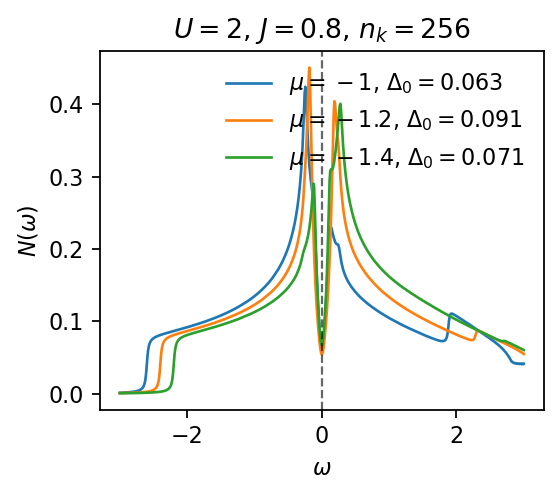

2639.2990913391113 seconds


In [4]:
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize


start_time = time.time()


def lorentzian(x, gamma):
    """Normalized Lorentzian used to broaden delta functions."""
    return gamma / np.pi / (x**2 + gamma**2)


def state_index(occ):
    """Map |n_a, n_b, n_c, n_d> to the integer Fock index."""
    return sum(int(n) << i for i, n in enumerate(occ))


def annihilation_operator(mode, n_modes=4):
    """Fermionic annihilation matrix for one mode in the occupation basis."""
    dim = 2**n_modes
    op = np.zeros((dim, dim), dtype=complex)

    for state in range(dim):
        if not ((state >> mode) & 1):
            continue

        new_state = state & ~(1 << mode)
        occupied_before = sum((state >> j) & 1 for j in range(mode))
        sign = (-1) ** occupied_before
        op[new_state, state] = sign

    return op


def thermal_weights(energies, beta):
    """Boltzmann weights normalized in a numerically stable way."""
    shifted = energies - np.min(energies)
    weights = np.exp(-beta * shifted)
    return weights / np.sum(weights)


def band_energy(kx, ky, mu, hop):
    """
    Dispersion used in wormsc.py:

        xi_k = -2(cos kx + cos ky)
               -4 t1 cos kx cos ky
               -4 t2(cos^2 kx + cos^2 ky - 1) - mu.
    """
    cx = np.cos(kx)
    cy = np.cos(ky)
    t1, t2 = hop
    return (
        -2.0 * (cx + cy)
        - 4.0 * t1 * cx * cy
        - 4.0 * t2 * (cx * cx + cy * cy - 1.0)
        - mu
    )


def pair_form_factor(kx, ky):
    """d-wave form factor cos(kx) - cos(ky)."""
    return np.cos(kx) - np.cos(ky)


def block_matrix_elements(kx, ky, mu, hop, U, Delta0):
    """
    Construct the block matrices for one four-mode Fermi-arc sector.

    Mode order:
        0: a = c_{k up}
        1: b = c_{k+Q down}
        2: c = c_{-k down}
        3: d = c_{-k-Q up}
    """
    xi_k = band_energy(kx, ky, mu, hop)
    xi_kq = band_energy(kx + np.pi, ky + np.pi, mu, hop)
    Delta_k = Delta0 * pair_form_factor(kx, ky)
    d = Delta_k
    dc = np.conjugate(Delta_k)

    h_sz_2 = np.array([[xi_k + xi_kq]], dtype=complex)
    basis_sz_2 = [(1, 0, 0, 1)]

    h_sz_minus_2 = np.array([[xi_k + xi_kq]], dtype=complex)
    basis_sz_minus_2 = [(0, 1, 1, 0)]

    h_sz_1_a = np.array(
        [
            [xi_k, dc],
            [d, xi_k + 2.0 * xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_1_a = [(1, 0, 0, 0), (1, 1, 0, 1)]

    h_sz_1_d = np.array(
        [
            [xi_kq, dc],
            [d, 2.0 * xi_k + xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_1_d = [(0, 0, 0, 1), (1, 0, 1, 1)]

    h_sz_minus_1_b = np.array(
        [
            [xi_kq, -dc],
            [-d, 2.0 * xi_k + xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_minus_1_b = [(0, 1, 0, 0), (1, 1, 1, 0)]

    h_sz_minus_1_c = np.array(
        [
            [xi_k, -dc],
            [-d, xi_k + 2.0 * xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_minus_1_c = [(0, 0, 1, 0), (0, 1, 1, 1)]

    h_sz_0_4 = np.array(
        [
            [0.0, dc, dc, 0.0],
            [d, 2.0 * xi_k, 0.0, -dc],
            [d, 0.0, 2.0 * xi_kq, -dc],
            [0.0, -d, -d, 2.0 * (xi_k + xi_kq + U)],
        ],
        dtype=complex,
    )
    basis_sz_0_4 = [
        (0, 0, 0, 0),
        (1, 0, 1, 0),
        (0, 1, 0, 1),
        (1, 1, 1, 1),
    ]

    h_interacting_pair = np.array([[xi_k + xi_kq + U]], dtype=complex)
    basis_ab = [(1, 1, 0, 0)]
    basis_cd = [(0, 0, 1, 1)]

    return [
        (h_sz_2, basis_sz_2),
        (h_sz_1_a, basis_sz_1_a),
        (h_sz_1_d, basis_sz_1_d),
        (h_sz_0_4, basis_sz_0_4),
        (h_interacting_pair, basis_ab),
        (h_interacting_pair, basis_cd),
        (h_sz_minus_1_b, basis_sz_minus_1_b),
        (h_sz_minus_1_c, basis_sz_minus_1_c),
        (h_sz_minus_2, basis_sz_minus_2),
    ]


def diagonalize_sector_block(kx, ky, mu, hop, U, Delta0):
    """
    Diagonalize all blocks and embed their eigenvectors into the full
    16-dimensional occupation basis of one four-mode sector.
    """
    energies_all = []
    vectors_all = []

    for h_block, basis_occ in block_matrix_elements(kx, ky, mu, hop, U, Delta0):
        energies, vectors = np.linalg.eigh(h_block)
        basis_indices = [state_index(occ) for occ in basis_occ]

        for n in range(len(energies)):
            full_vector = np.zeros(16, dtype=complex)
            full_vector[basis_indices] = vectors[:, n]
            energies_all.append(energies[n])
            vectors_all.append(full_vector)

    order = np.argsort(np.real(energies_all))
    energies_all = np.array(energies_all, dtype=float)[order]
    vectors_all = np.array(vectors_all, dtype=complex).T[:, order]

    return energies_all, vectors_all


def sector_operators():
    """Return annihilation operators and the d-wave pair operator in one sector."""
    c_ops = [annihilation_operator(i) for i in range(4)]
    pair_op = c_ops[2] @ c_ops[0]
    return c_ops, pair_op


C_OPS, PAIR_OP = sector_operators()


def pair_expectation_for_k(kx, ky, mu, hop, U, Delta0, beta):
    """Thermal expectation value of c_{-k down} c_{k up}."""
    energies, vectors = diagonalize_sector_block(kx, ky, mu, hop, U, Delta0)
    rho = thermal_weights(energies, beta)
    pair_eigenbasis = vectors.conj().T @ PAIR_OP @ vectors
    return np.sum(rho * np.diag(pair_eigenbasis))


def triangular_kmesh(nk1d):
    """Triangular k mesh 0 <= ky <= kx <= pi for the gap equation."""
    points = []
    weights = []
    for ix in range(nk1d):
        for iy in range(ix + 1):
            kx = ix * np.pi / nk1d
            ky = iy * np.pi / nk1d
            points.append((kx, ky))
            weights.append(0.5 if ix == iy else 1.0)
    return np.array(points, dtype=float), np.array(weights, dtype=float)


def full_bz_midpoint_mesh(nk1d):
    """Full-BZ midpoint mesh used for the DOS k-sum."""
    grid = -np.pi + (np.arange(nk1d) + 0.5) * (2.0 * np.pi / nk1d)
    kx_grid, ky_grid = np.meshgrid(grid, grid, indexing="ij")
    return kx_grid.ravel(), ky_grid.ravel()


def quarter_bz_midpoint_mesh(nk1d):
    """
    Quarter-BZ midpoint mesh used for the DOS k-sum.

    The region is 0 <= kx < pi and 0 <= ky < pi. For the averaged DOS,
    no extra factor of 4 is needed because the full-BZ average equals the
    quarter-BZ average when C4 symmetry holds.
    """
    grid = (np.arange(nk1d) + 0.5) * (np.pi / nk1d)
    kx_grid, ky_grid = np.meshgrid(grid, grid, indexing="ij")
    return kx_grid.ravel(), ky_grid.ravel()


def solve_gap_delta0(k_points, k_weights, J, mu, hop, U, beta, bracket=(1e-8, 1.0)):
    """
    Solve the d-wave gap equation using scipy.root_scalar:

        Delta0 = -J < g_k <c_-k down c_k up> >.
    """

    def new_delta(delta0):
        vals = []
        for (kx, ky), weight in zip(k_points, k_weights):
            gk = pair_form_factor(kx, ky)
            pair_avg = pair_expectation_for_k(kx, ky, mu, hop, U, delta0, beta)
            vals.append(weight * gk * pair_avg)
        return -J * np.sum(vals) / np.sum(k_weights)

    def residual(delta0):
        return np.real(new_delta(delta0) - delta0)

    lo, hi = bracket
    f_lo = residual(lo)
    f_hi = residual(hi)

    while f_lo * f_hi > 0 and hi < 20.0:
        hi *= 2.0
        f_hi = residual(hi)

    if f_lo * f_hi > 0:
        return 0.0

    sol = optimize.root_scalar(residual, bracket=(lo, hi), xtol=1e-10, rtol=1e-10)
    return sol.root if sol.converged else 0.0


def spectral_function_for_k_block(
    kx,
    ky,
    omega_values,
    mu,
    hop,
    U,
    Delta0,
    beta,
    gamma,
    mode=0,
):
    """
    Compute A(k, omega) in one four-mode sector using the Lehmann formula.

    mode=0 corresponds to c_{k up}.
    mode=1 corresponds to c_{k+Q down}.
    mode=2 corresponds to c_{-k down}.
    mode=3 corresponds to c_{-k-Q up}.
    """
    energies, vectors = diagonalize_sector_block(kx, ky, mu, hop, U, Delta0)
    rho = thermal_weights(energies, beta)

    c_op = C_OPS[mode]
    cd_op = c_op.conj().T

    c_eigenbasis = vectors.conj().T @ c_op @ vectors
    cd_eigenbasis = vectors.conj().T @ cd_op @ vectors

    spectrum = np.zeros_like(omega_values, dtype=float)

    for m, e_m in enumerate(energies):
        for n, e_n in enumerate(energies):
            addition_weight = rho[m] * abs(cd_eigenbasis[n, m]) ** 2
            removal_weight = rho[m] * abs(c_eigenbasis[n, m]) ** 2

            spectrum += addition_weight * lorentzian(omega_values - (e_n - e_m), gamma)
            spectrum += removal_weight * lorentzian(omega_values + (e_n - e_m), gamma)

    return spectrum


def fermi_arc_density_of_states(
    kx_values,
    ky_values,
    omega_values,
    mu,
    hop,
    U,
    Delta0,
    beta,
    gamma,
    mode=0,
    spin_degeneracy=1.0,
):
    """
    Compute the k-summed density of states:

        N(omega) = spin_degeneracy * mean_k A_mode(k, omega).

    With mode=0 this gives the spin-up DOS for c_{k up}.
    Use spin_degeneracy=2 if you want the spin-summed DOS.
    """
    dos = np.zeros_like(omega_values, dtype=float)
    n_k = len(kx_values)

    for i, (kx, ky) in enumerate(zip(kx_values, ky_values), start=1):
        dos += spectral_function_for_k_block(
            kx,
            ky,
            omega_values,
            mu=mu,
            hop=hop,
            U=U,
            Delta0=Delta0,
            beta=beta,
            gamma=gamma,
            mode=mode,
        )

        if i % max(1, n_k // 10) == 0:
            print(f"DOS k-sum progress: {i}/{n_k}")

    return spin_degeneracy * dos / n_k


# -------------------------- parameters --------------------------
hop = np.array([-0.2, 0.1])
U = 2
J = 0.8
mu_list = [-1.0, -1.2, -1.4]

temperature = 1e-10 * J
beta = 1.0 / temperature
gamma = 0.02

use_self_consistent_delta = True
Delta0 = 0.0

omegas = np.linspace(-3.0, 3.0, 600)

# Increase nk_dos for smoother DOS. The cost scales as nk_dos**2.
# This is a quarter-BZ grid. It gives the same averaged DOS as the full BZ
# but with four times fewer k points.
nk_gap = 64
nk_dos = 256
kx_values, ky_values = quarter_bz_midpoint_mesh(nk_dos)
gap_points, gap_weights = triangular_kmesh(nk_gap)

dos_list = []
delta_list = []

for mu in mu_list:
    mu_start = time.time()

    if use_self_consistent_delta:
        Delta0 = solve_gap_delta0(
            gap_points,
            gap_weights,
            J,
            mu,
            hop,
            U,
            beta,
            bracket=(1e-8, J),
        )
    else:
        Delta0 = 0.0

    print(f"mu={mu:.8g}, self-consistent Delta0={Delta0:.10f}")

    dos = fermi_arc_density_of_states(
        kx_values,
        ky_values,
        omegas,
        mu=mu,
        hop=hop,
        U=U,
        Delta0=Delta0,
        beta=beta,
        gamma=gamma,
        mode=0,
        spin_degeneracy=1.0,
    )

    dos_list.append(dos)
    delta_list.append(Delta0)

    tag = f"U={U}_mu={mu}_J={J}_nkdos={nk_dos}_gamma={gamma}"
    np.save(f"sc_dos_{tag}.npy", dos)

    print(f"Saved sc_dos_{tag}.npy")
    print(f"Finished mu={mu:.8g} in {time.time() - mu_start:.2f} seconds")

dos_array = np.array(dos_list, dtype=float)
delta_array = np.array(delta_list, dtype=float)
mu_array = np.array(mu_list, dtype=float)


# -------------------------- plot --------------------------
plt.figure(figsize=(3.6, 3.2), dpi=160)

for mu, Delta0, dos in zip(mu_array, delta_array, dos_array):
    plt.plot(
        omegas,
        dos,
        linewidth=1.2,
        label=rf"$\mu={mu:g}$, $\Delta_0={Delta0:.3f}$",
    )

plt.axvline(0.0, color="black", linestyle="--", linewidth=1.0, alpha=0.6)
plt.xlabel(r"$\omega$")
plt.ylabel(r"$N(\omega)$")
plt.title(rf"$U={U}$, $J={J}$, $n_k={nk_dos}$")
plt.legend(frameon=False)
plt.tight_layout()

# plt.savefig(f"sc_dos_U={U}_J={J}_nkdos={nk_dos}_gamma={gamma}.png", bbox_inches="tight")
# plt.close()
plt.show()

print(time.time() - start_time, "seconds")


mu=-1, self-consistent Delta0=0.0000000000
DOS k-sum progress: 6553/65536
DOS k-sum progress: 13106/65536
DOS k-sum progress: 19659/65536
DOS k-sum progress: 26212/65536
DOS k-sum progress: 32765/65536
DOS k-sum progress: 39318/65536
DOS k-sum progress: 45871/65536
DOS k-sum progress: 52424/65536
DOS k-sum progress: 58977/65536
DOS k-sum progress: 65530/65536
Saved normal_dos_U=2_mu=-1.0_J=0.8_nkdos=256_gamma=0.02.npy
Finished mu=-1 in 221.02 seconds
mu=-1.2, self-consistent Delta0=0.0000000000
DOS k-sum progress: 6553/65536
DOS k-sum progress: 13106/65536
DOS k-sum progress: 19659/65536
DOS k-sum progress: 26212/65536
DOS k-sum progress: 32765/65536
DOS k-sum progress: 39318/65536
DOS k-sum progress: 45871/65536
DOS k-sum progress: 52424/65536
DOS k-sum progress: 58977/65536
DOS k-sum progress: 65530/65536
Saved normal_dos_U=2_mu=-1.2_J=0.8_nkdos=256_gamma=0.02.npy
Finished mu=-1.2 in 247.00 seconds
mu=-1.4, self-consistent Delta0=0.0000000000
DOS k-sum progress: 6553/65536
DOS k-sum 

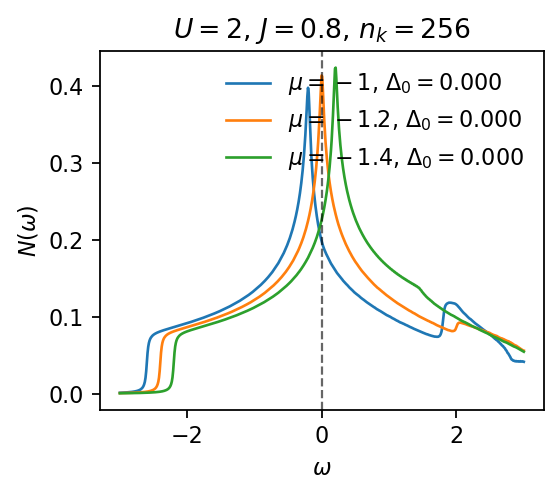

1345.1823835372925 seconds


In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize


start_time = time.time()


def lorentzian(x, gamma):
    """Normalized Lorentzian used to broaden delta functions."""
    return gamma / np.pi / (x**2 + gamma**2)


def state_index(occ):
    """Map |n_a, n_b, n_c, n_d> to the integer Fock index."""
    return sum(int(n) << i for i, n in enumerate(occ))


def annihilation_operator(mode, n_modes=4):
    """Fermionic annihilation matrix for one mode in the occupation basis."""
    dim = 2**n_modes
    op = np.zeros((dim, dim), dtype=complex)

    for state in range(dim):
        if not ((state >> mode) & 1):
            continue

        new_state = state & ~(1 << mode)
        occupied_before = sum((state >> j) & 1 for j in range(mode))
        sign = (-1) ** occupied_before
        op[new_state, state] = sign

    return op


def thermal_weights(energies, beta):
    """Boltzmann weights normalized in a numerically stable way."""
    shifted = energies - np.min(energies)
    weights = np.exp(-beta * shifted)
    return weights / np.sum(weights)


def band_energy(kx, ky, mu, hop):
    """
    Dispersion used in wormsc.py:

        xi_k = -2(cos kx + cos ky)
               -4 t1 cos kx cos ky
               -4 t2(cos^2 kx + cos^2 ky - 1) - mu.
    """
    cx = np.cos(kx)
    cy = np.cos(ky)
    t1, t2 = hop
    return (
        -2.0 * (cx + cy)
        - 4.0 * t1 * cx * cy
        - 4.0 * t2 * (cx * cx + cy * cy - 1.0)
        - mu
    )


def pair_form_factor(kx, ky):
    """d-wave form factor cos(kx) - cos(ky)."""
    return np.cos(kx) - np.cos(ky)


def block_matrix_elements(kx, ky, mu, hop, U, Delta0):
    """
    Construct the block matrices for one four-mode Fermi-arc sector.

    Mode order:
        0: a = c_{k up}
        1: b = c_{k+Q down}
        2: c = c_{-k down}
        3: d = c_{-k-Q up}
    """
    xi_k = band_energy(kx, ky, mu, hop)
    xi_kq = band_energy(kx + np.pi, ky + np.pi, mu, hop)
    Delta_k = Delta0 * pair_form_factor(kx, ky)
    d = Delta_k
    dc = np.conjugate(Delta_k)

    h_sz_2 = np.array([[xi_k + xi_kq]], dtype=complex)
    basis_sz_2 = [(1, 0, 0, 1)]

    h_sz_minus_2 = np.array([[xi_k + xi_kq]], dtype=complex)
    basis_sz_minus_2 = [(0, 1, 1, 0)]

    h_sz_1_a = np.array(
        [
            [xi_k, dc],
            [d, xi_k + 2.0 * xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_1_a = [(1, 0, 0, 0), (1, 1, 0, 1)]

    h_sz_1_d = np.array(
        [
            [xi_kq, dc],
            [d, 2.0 * xi_k + xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_1_d = [(0, 0, 0, 1), (1, 0, 1, 1)]

    h_sz_minus_1_b = np.array(
        [
            [xi_kq, -dc],
            [-d, 2.0 * xi_k + xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_minus_1_b = [(0, 1, 0, 0), (1, 1, 1, 0)]

    h_sz_minus_1_c = np.array(
        [
            [xi_k, -dc],
            [-d, xi_k + 2.0 * xi_kq + U],
        ],
        dtype=complex,
    )
    basis_sz_minus_1_c = [(0, 0, 1, 0), (0, 1, 1, 1)]

    h_sz_0_4 = np.array(
        [
            [0.0, dc, dc, 0.0],
            [d, 2.0 * xi_k, 0.0, -dc],
            [d, 0.0, 2.0 * xi_kq, -dc],
            [0.0, -d, -d, 2.0 * (xi_k + xi_kq + U)],
        ],
        dtype=complex,
    )
    basis_sz_0_4 = [
        (0, 0, 0, 0),
        (1, 0, 1, 0),
        (0, 1, 0, 1),
        (1, 1, 1, 1),
    ]

    h_interacting_pair = np.array([[xi_k + xi_kq + U]], dtype=complex)
    basis_ab = [(1, 1, 0, 0)]
    basis_cd = [(0, 0, 1, 1)]

    return [
        (h_sz_2, basis_sz_2),
        (h_sz_1_a, basis_sz_1_a),
        (h_sz_1_d, basis_sz_1_d),
        (h_sz_0_4, basis_sz_0_4),
        (h_interacting_pair, basis_ab),
        (h_interacting_pair, basis_cd),
        (h_sz_minus_1_b, basis_sz_minus_1_b),
        (h_sz_minus_1_c, basis_sz_minus_1_c),
        (h_sz_minus_2, basis_sz_minus_2),
    ]


def diagonalize_sector_block(kx, ky, mu, hop, U, Delta0):
    """
    Diagonalize all blocks and embed their eigenvectors into the full
    16-dimensional occupation basis of one four-mode sector.
    """
    energies_all = []
    vectors_all = []

    for h_block, basis_occ in block_matrix_elements(kx, ky, mu, hop, U, Delta0):
        energies, vectors = np.linalg.eigh(h_block)
        basis_indices = [state_index(occ) for occ in basis_occ]

        for n in range(len(energies)):
            full_vector = np.zeros(16, dtype=complex)
            full_vector[basis_indices] = vectors[:, n]
            energies_all.append(energies[n])
            vectors_all.append(full_vector)

    order = np.argsort(np.real(energies_all))
    energies_all = np.array(energies_all, dtype=float)[order]
    vectors_all = np.array(vectors_all, dtype=complex).T[:, order]

    return energies_all, vectors_all


def sector_operators():
    """Return annihilation operators and the d-wave pair operator in one sector."""
    c_ops = [annihilation_operator(i) for i in range(4)]
    pair_op = c_ops[2] @ c_ops[0]
    return c_ops, pair_op


C_OPS, PAIR_OP = sector_operators()


def pair_expectation_for_k(kx, ky, mu, hop, U, Delta0, beta):
    """Thermal expectation value of c_{-k down} c_{k up}."""
    energies, vectors = diagonalize_sector_block(kx, ky, mu, hop, U, Delta0)
    rho = thermal_weights(energies, beta)
    pair_eigenbasis = vectors.conj().T @ PAIR_OP @ vectors
    return np.sum(rho * np.diag(pair_eigenbasis))


def triangular_kmesh(nk1d):
    """Triangular k mesh 0 <= ky <= kx <= pi for the gap equation."""
    points = []
    weights = []
    for ix in range(nk1d):
        for iy in range(ix + 1):
            kx = ix * np.pi / nk1d
            ky = iy * np.pi / nk1d
            points.append((kx, ky))
            weights.append(0.5 if ix == iy else 1.0)
    return np.array(points, dtype=float), np.array(weights, dtype=float)


def full_bz_midpoint_mesh(nk1d):
    """Full-BZ midpoint mesh used for the DOS k-sum."""
    grid = -np.pi + (np.arange(nk1d) + 0.5) * (2.0 * np.pi / nk1d)
    kx_grid, ky_grid = np.meshgrid(grid, grid, indexing="ij")
    return kx_grid.ravel(), ky_grid.ravel()


def quarter_bz_midpoint_mesh(nk1d):
    """
    Quarter-BZ midpoint mesh used for the DOS k-sum.

    The region is 0 <= kx < pi and 0 <= ky < pi. For the averaged DOS,
    no extra factor of 4 is needed because the full-BZ average equals the
    quarter-BZ average when C4 symmetry holds.
    """
    grid = (np.arange(nk1d) + 0.5) * (np.pi / nk1d)
    kx_grid, ky_grid = np.meshgrid(grid, grid, indexing="ij")
    return kx_grid.ravel(), ky_grid.ravel()


def solve_gap_delta0(k_points, k_weights, J, mu, hop, U, beta, bracket=(1e-8, 1.0)):
    """
    Solve the d-wave gap equation using scipy.root_scalar:

        Delta0 = -J < g_k <c_-k down c_k up> >.
    """

    def new_delta(delta0):
        vals = []
        for (kx, ky), weight in zip(k_points, k_weights):
            gk = pair_form_factor(kx, ky)
            pair_avg = pair_expectation_for_k(kx, ky, mu, hop, U, delta0, beta)
            vals.append(weight * gk * pair_avg)
        return -J * np.sum(vals) / np.sum(k_weights)

    def residual(delta0):
        return np.real(new_delta(delta0) - delta0)

    lo, hi = bracket
    f_lo = residual(lo)
    f_hi = residual(hi)

    while f_lo * f_hi > 0 and hi < 20.0:
        hi *= 2.0
        f_hi = residual(hi)

    if f_lo * f_hi > 0:
        return 0.0

    sol = optimize.root_scalar(residual, bracket=(lo, hi), xtol=1e-10, rtol=1e-10)
    return sol.root if sol.converged else 0.0


def spectral_function_for_k_block(
    kx,
    ky,
    omega_values,
    mu,
    hop,
    U,
    Delta0,
    beta,
    gamma,
    mode=0,
):
    """
    Compute A(k, omega) in one four-mode sector using the Lehmann formula.

    mode=0 corresponds to c_{k up}.
    mode=1 corresponds to c_{k+Q down}.
    mode=2 corresponds to c_{-k down}.
    mode=3 corresponds to c_{-k-Q up}.
    """
    energies, vectors = diagonalize_sector_block(kx, ky, mu, hop, U, Delta0)
    rho = thermal_weights(energies, beta)

    c_op = C_OPS[mode]
    cd_op = c_op.conj().T

    c_eigenbasis = vectors.conj().T @ c_op @ vectors
    cd_eigenbasis = vectors.conj().T @ cd_op @ vectors

    spectrum = np.zeros_like(omega_values, dtype=float)

    for m, e_m in enumerate(energies):
        for n, e_n in enumerate(energies):
            addition_weight = rho[m] * abs(cd_eigenbasis[n, m]) ** 2
            removal_weight = rho[m] * abs(c_eigenbasis[n, m]) ** 2

            spectrum += addition_weight * lorentzian(omega_values - (e_n - e_m), gamma)
            spectrum += removal_weight * lorentzian(omega_values + (e_n - e_m), gamma)

    return spectrum


def fermi_arc_density_of_states(
    kx_values,
    ky_values,
    omega_values,
    mu,
    hop,
    U,
    Delta0,
    beta,
    gamma,
    mode=0,
    spin_degeneracy=1.0,
):
    """
    Compute the k-summed density of states:

        N(omega) = spin_degeneracy * mean_k A_mode(k, omega).

    With mode=0 this gives the spin-up DOS for c_{k up}.
    Use spin_degeneracy=2 if you want the spin-summed DOS.
    """
    dos = np.zeros_like(omega_values, dtype=float)
    n_k = len(kx_values)

    for i, (kx, ky) in enumerate(zip(kx_values, ky_values), start=1):
        dos += spectral_function_for_k_block(
            kx,
            ky,
            omega_values,
            mu=mu,
            hop=hop,
            U=U,
            Delta0=Delta0,
            beta=beta,
            gamma=gamma,
            mode=mode,
        )

        if i % max(1, n_k // 10) == 0:
            print(f"DOS k-sum progress: {i}/{n_k}")

    return spin_degeneracy * dos / n_k


# -------------------------- parameters --------------------------
hop = np.array([-0.2, 0.1])
U = 2
J = 0.8
mu_list = [-1.0, -1.2, -1.4]

temperature = 1e-10 * J
beta = 1.0 / temperature
gamma = 0.02

use_self_consistent_delta = False
Delta0 = 0.0

omegas = np.linspace(-3.0, 3.0, 600)

# Increase nk_dos for smoother DOS. The cost scales as nk_dos**2.
# This is a quarter-BZ grid. It gives the same averaged DOS as the full BZ
# but with four times fewer k points.
nk_gap = 64
nk_dos = 256
kx_values, ky_values = quarter_bz_midpoint_mesh(nk_dos)
gap_points, gap_weights = triangular_kmesh(nk_gap)

dos_list = []
delta_list = []

for mu in mu_list:
    mu_start = time.time()

    if use_self_consistent_delta:
        Delta0 = solve_gap_delta0(
            gap_points,
            gap_weights,
            J,
            mu,
            hop,
            U,
            beta,
            bracket=(1e-8, J),
        )
    else:
        Delta0 = 0.0

    print(f"mu={mu:.8g}, self-consistent Delta0={Delta0:.10f}")

    dos = fermi_arc_density_of_states(
        kx_values,
        ky_values,
        omegas,
        mu=mu,
        hop=hop,
        U=U,
        Delta0=Delta0,
        beta=beta,
        gamma=gamma,
        mode=0,
        spin_degeneracy=1.0,
    )

    dos_list.append(dos)
    delta_list.append(Delta0)

    tag = f"U={U}_mu={mu}_J={J}_nkdos={nk_dos}_gamma={gamma}"
    np.save(f"normal_dos_{tag}.npy", dos)

    print(f"Saved normal_dos_{tag}.npy")
    print(f"Finished mu={mu:.8g} in {time.time() - mu_start:.2f} seconds")

dos_array = np.array(dos_list, dtype=float)
delta_array = np.array(delta_list, dtype=float)
mu_array = np.array(mu_list, dtype=float)


# -------------------------- plot --------------------------
plt.figure(figsize=(3.6, 3.2), dpi=160)

for mu, Delta0, dos in zip(mu_array, delta_array, dos_array):
    plt.plot(
        omegas,
        dos,
        linewidth=1.2,
        label=rf"$\mu={mu:g}$, $\Delta_0={Delta0:.3f}$",
    )

plt.axvline(0.0, color="black", linestyle="--", linewidth=1.0, alpha=0.6)
plt.xlabel(r"$\omega$")
plt.ylabel(r"$N(\omega)$")
plt.title(rf"$U={U}$, $J={J}$, $n_k={nk_dos}$")
plt.legend(frameon=False)
plt.tight_layout()

# plt.savefig(f"normal_dos_U={U}_J={J}_nkdos={nk_dos}_gamma={gamma}.png", bbox_inches="tight")
# plt.close()
plt.show()

print(time.time() - start_time, "seconds")
